In [5]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import pandas as pd

## 2 getting the data

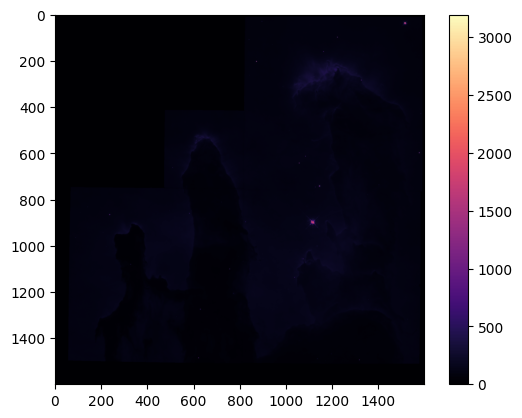

In [20]:
image = np.loadtxt("astro_image.csv")

plt.imshow(image, cmap='magma')
plt.colorbar()
plt.show()

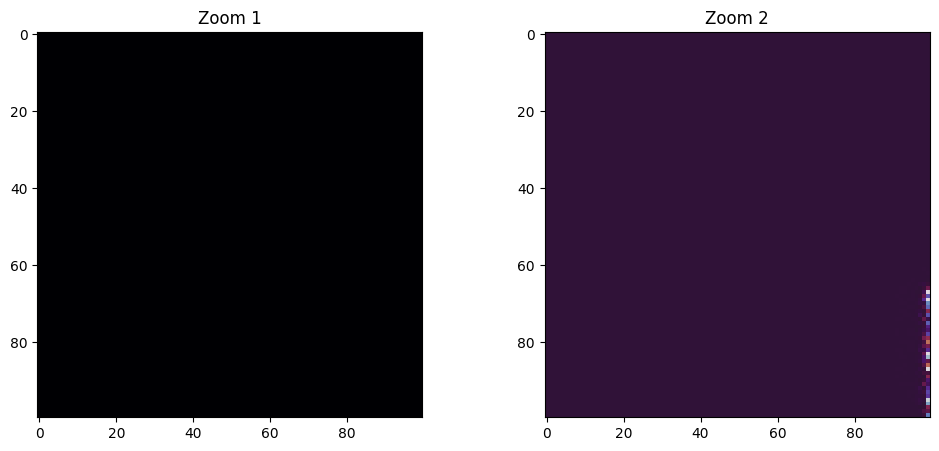

In [22]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].imshow(image[200:300, 200:300], cmap='magma')
axs[0].set_title("Zoom 1")

axs[1].imshow(image[350:450, 350:450], cmap='twilight')
axs[1].set_title("Zoom 2")

plt.show()

## 3.2 pandas and ramen

**1. what are the column names in this dataset?**
the column names are "Review #", "Brand", "Variety", "Style", "Country", "Stars", and "Top Ten".

In [32]:
import pandas as pd

ramen = pd.read_csv("ramen-ratings.csv")
ramen.columns

Index(['Review #', 'Brand', 'Variety', 'Style', 'Country', 'Stars', 'Top Ten'], dtype='object')

**2. what is the ramen style of the 27th entry?**

The style is pack

In [33]:
ramen.loc[26, "Style"]

'Pack'

**3. How many different ramen brands are there?**

There are 355 different ramen brands

In [34]:
ramen['Brand'].nunique()

355

**4. sort the dataset by brand names**

sorting the brand names in alphanumeric order: '1 To 3 Noodles', '7 Select', and 'A-One' are the first few listed out of the 355 different brands.

In [38]:
ramen_sorted = ramen.sort_values('Brand')
ramen_sorted.head()

,Review #,Brand,Variety,Style,Country,Stars,Top Ten
229,2351,1 To 3 Noodles,Chatpat Masala,Pack,India,4,NaN
456,2124,7 Select,Nissin Instant Noodles Tom Yum Seafood Creamy ...,Bowl,Thailand,3.5,NaN
463,2117,7 Select,Nissin Instant Noodles Shrimp Ma Nao Lui Suan ...,Bowl,Thailand,4,NaN
877,1703,7 Select/Nissin,Super Tom Yum Shrimp,Cup,Thailand,3.5,NaN
911,1669,A-One,Mi Ly Instant Noodles Mi Chay Vegetarian Flavor,Cup,Vietnam,1.25,NaN


**5. how many ramen brands are made in the usa?**

49 brands are made in the usa

In [36]:
usa_ramen = ramen[ramen['Country'] == 'USA']
usa_ramen['Brand'].nunique()

49

**6. how many ramen brands in the USA make pack-style ramen?**

27 brands in the usa make pack-style ramen

In [40]:
pack_usa = ramen[(ramen["Country"] == "USA") & (ramen["Style"] == "Pack")]
pack_usa["Brand"].nunique()


27

**7. which ramen brands have been in the top 10?**

MAMA, Prima Taste, Prima, Tseng Noodles, Wugudaochang, A-Sha Dry Noodle, MyKuali, CarJEN, Maruchan, Mamee, Mama, Sapporo Ichiban, Nongshim, Samyang Foods, Paldo, Indomie, Koka, Mi Sedaap, Nissin, Myojo, and Doll have all been in the top 10

In [42]:
top10_brands = ramen[ramen["Top Ten"].notna()]["Brand"].unique()
top10_brands

array(['MAMA', 'Prima Taste', 'Prima', 'Tseng Noodles', 'Wugudaochang',
       'A-Sha Dry Noodle', 'MyKuali', 'CarJEN', 'Maruchan', 'Mamee',
       'Mama', 'Sapporo Ichiban', 'Nongshim', 'Samyang Foods', 'Paldo',
       'Indomie', 'Koka', 'Mi Sedaap', 'Nissin', 'Myojo', 'Doll'],
      dtype=object)

## 3.3 linear regression

In [45]:
from astropy.table import Table

table = Table.read("global_CCl4_MM.dat", format="ascii")
table

CCl4ottoyr,CCl4ottomon,CCl4ottoNHm,CCl4ottoNHsd,CCl4ottoSHm,CCl4ottoSHsd,CCl4ottoGLm,CCl4ottoGLsd
int64,int64,float64,float64,float64,float64,float64,float64
1996,1,nan,nan,nan,nan,nan,nan
1996,2,nan,nan,nan,nan,nan,nan
1996,3,nan,nan,nan,nan,nan,nan
1996,4,105.318,0.197,102.969,0.238,104.144,0.155
1996,5,105.032,0.193,102.754,0.287,103.893,0.174
1996,6,105.327,0.277,103.086,0.273,104.207,0.191
1996,7,105.25,0.171,103.021,0.233,104.136,0.147
1996,8,104.855,0.239,102.817,0.213,103.836,0.161
1996,9,104.909,0.248,102.813,0.441,103.861,0.254


In [47]:
df = table.to_pandas()

df = df[[
    "CCl4ottoyr",
    "CCl4ottomon",
    "CCl4ottoGLm",
    "CCl4ottoGLsd"
]]

df.head()

,CCl4ottoyr,CCl4ottomon,CCl4ottoGLm,CCl4ottoGLsd
0,1996,1,NaN,NaN
1,1996,2,NaN,NaN
2,1996,3,NaN,NaN
3,1996,4,104.144,0.155
4,1996,5,103.893,0.174


In [49]:
df["date"] = df["CCl4ottoyr"] + (df["CCl4ottomon"] - 1) / 12

df = df.rename(columns={
    "CCl4ottoGLm": "global mean concentration",
    "CCl4ottoGLsd": "global mean concentration sd"
})

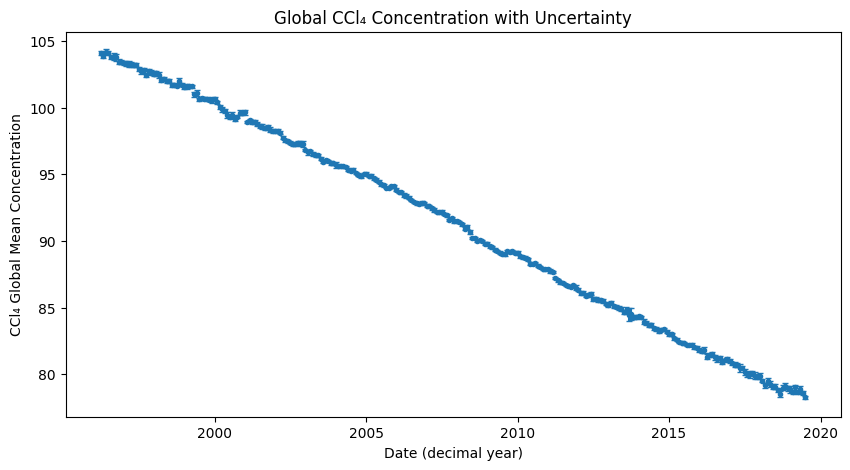

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.errorbar(
    df["date"],
    df["global mean concentration"],
    yerr=df["global mean concentration sd"],
    fmt="o",
    markersize=3,
    capsize=2,
)

plt.xlabel("Date (decimal year)")
plt.ylabel("CCl₄ Global Mean Concentration")
plt.title("Global CCl₄ Concentration with Uncertainty")
plt.show()


In [63]:
x = df["date"].to_numpy()
y = df["global mean concentration"].to_numpy()
sigma = df["global mean concentration sd"].to_numpy()

mask = (~np.isnan(x)) & (~np.isnan(y)) & (~np.isnan(sigma))
x_clean = x[mask]
y_clean = y[mask]
sigma_clean = sigma[mask]

print("Clean sizes:", len(x_clean), len(y_clean), len(sigma_clean))

sigma_clean[sigma_clean <= 0] = 1e-12

m, b = np.polyfit(x_clean, y_clean, 1, w=1/sigma_clean)

print("Slope =", m)
print("Intercept =", b)

model = m*x + b

Clean sizes: 280 280 280
Slope = -1.1544097066171208
Intercept = 2409.2192083504005


In [65]:
y_exp = m * x_clean + b

N = len(x_clean)

chi2_red = (1/(N-1)) * np.sum(((y_exp - y_clean) / sigma_clean)**2)

chi2_red


np.float64(4.420929624597239)

7. The reduced chi-square value is ~4.42093. This means that the model does not match the data well as it is greater than 3. This is probably because using a linear fit does not accurately capture the bend in the actual data represented as a curve.